# Syntactic Drop comparision short vs long messages

In Semantic Communication, we compress sentences into fixed-size mathematical vectors (the latent space) , not usual word embeddings but atually semantic embeddings  

**The Information Bottleneck Theory** states that as a sentence gets longer, the fixed-size vector doesn't have enough space to store every syntactic detail. Therefore, the network naturally drops the *syntactic* structure to preserve the *semantic* structure.

In this notebook, we use the `BART` sequence-to-sequence model to encode a **Short Sentence** and a **Long Sentence**, inject AWGN noise into their vectoer space, decode them back to text, and compare how fast they lose their exact word-for-word accuracy (measured by BLEU and ROUGE scores).

In [27]:

!pip install nltk rouge-score matplotlib --quiet

import torch
import matplotlib.pyplot as plt
from transformers import BartTokenizer, BartForConditionalGeneration
from transformers.modeling_outputs import BaseModelOutput
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

print("installed all")

installed all


### loading bart , it is an generative autoencoder
Unlike our previous notebook that only used an Encoder, BART has both an Encoder and a Decoder. This allows us to actually turn the noisy vectors *back into strings*!

In [28]:
tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')
model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')
model.eval() # Set to evaluation mode
print("BART Loaded!")

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 5405.81it/s]


BART Loaded!


### Step 2: Defining the Sentences
We define one short sentence (easy to compress) and one long sentence (hard to compress).

In [29]:
short_sentence = "im grinding this summer"

long_sentence = "if you ever feel fear while turning the pages , just remember you are the author not the reader"

print("Short:", short_sentence)
print("Long:", long_sentence)

Short: im grinding this summer
Long: if you ever feel fear while turning the pages , just remember you are the author not the reader


### The transmission function
This function will encode the text, inject AWGN into the network, and then ask the decoder to guess what the original sentence was

In [30]:
def transmit_with_noise(text, noise_std_dev=0.1):
    #text to token
    input_ids = tokenizer(text, return_tensors='pt').input_ids
    
    with torch.no_grad():
        #get the hidden state
        encoder_outputs = model.get_encoder()(input_ids=input_ids)
        hidden_states = encoder_outputs.last_hidden_state
        
        #noise
        noise = torch.randn_like(hidden_states) * noise_std_dev
        noisy_hidden_states = hidden_states + noise
        
        #unwrap for demodulation
        noisy_encoder_outputs = BaseModelOutput(last_hidden_state=noisy_hidden_states)
        
        #noisy text to token
        output_ids = model.generate(encoder_outputs=noisy_encoder_outputs, max_length=50)
        
    #token to string
    decoded_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded_text

print("Transmission function ready.")

Transmission function ready.


### Step 4: Simulating Noise Sweeps and Tracking Metrics
We will slowly increase the noise from `0.0` to `1.5` and measure the syntactic degradation using BLEU and ROUGE-L.

In [31]:
noise_levels = [0.0, 0.01,0.02,0.03,0.04, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 1.0 ,1.5]
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method1

results_short = {'bleu': [], 'rouge': []}
results_long = {'bleu': [], 'rouge': []}


for noise in noise_levels:
    print(f"[ SNR Noise Level: {noise} ]")
    
    for sentence_type, sentence, results_dict in [
        ("SHORT", short_sentence, results_short), 
        ("LONG ", long_sentence, results_long)
    ]:
        # Transmit
        decoded = transmit_with_noise(sentence, noise)
        
        # Calculate BLEU (Word overlap precision)
        reference = [sentence.split()]
        candidate = decoded.split()
        bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
        
        # Calculate ROUGE-L (Longest common subsequence)
        rouge = scorer.score(sentence, decoded)['rougeL'].fmeasure
        
        results_dict['bleu'].append(bleu)
        results_dict['rouge'].append(rouge)
        
        # Print outputs for high/low noise to see the hallucination visually
        if noise in [0.0, 0.01,0.02,0.03,0.04, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 1.0 ,1.5]:
            print(f"  {sentence_type} Sent | Decoded: '{decoded}'")
    if noise in [0.0, 0.01,0.02,0.03,0.04, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 1.0 ,1.5]: print("-" * 40)
    
print("\nDONE")

[ SNR Noise Level: 0.0 ]
  SHORT Sent | Decoded: 'im grinding this summer'
  LONG  Sent | Decoded: 'if you ever feel fear while turning the pages , just remember you are the author not the reader'
----------------------------------------
[ SNR Noise Level: 0.01 ]
  SHORT Sent | Decoded: 'im grinding this summer'
  LONG  Sent | Decoded: 'if you ever feel fear while turning the pages , just remember you are the author not the reader'
----------------------------------------
[ SNR Noise Level: 0.02 ]
  SHORT Sent | Decoded: 'im grinding this summer'
  LONG  Sent | Decoded: 'if you ever feel fear while turning the pages , just remember you are the author not the reader'
----------------------------------------
[ SNR Noise Level: 0.03 ]
  SHORT Sent | Decoded: 'im grinding this summer'
  LONG  Sent | Decoded: 'if you ever feel fear while turning the pages , just remember you are the author not the reader'
----------------------------------------
[ SNR Noise Level: 0.04 ]
  SHORT Sent | Deco

### Visualization: BLEU and ROUGE-L Overlap Charts
Now we plot how fast the exact grammatical syntax dies under noise.

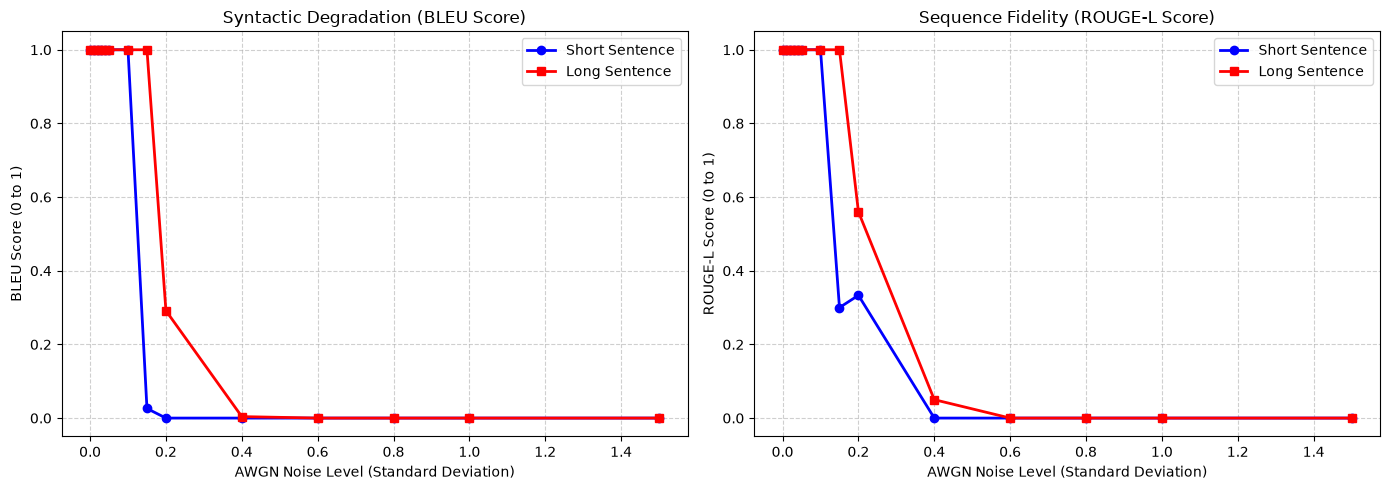

In [32]:
plt.figure(figsize=(14, 5))

# --- BLEU SCORE CHART ---
plt.subplot(1, 2, 1)
plt.plot(noise_levels, results_short['bleu'], marker='o', color='blue', label='Short Sentence', linewidth=2)
plt.plot(noise_levels, results_long['bleu'], marker='s', color='red', label='Long Sentence', linewidth=2)
plt.title('Syntactic Degradation (BLEU Score)')
plt.xlabel('AWGN Noise Level (Standard Deviation)')
plt.ylabel('BLEU Score (0 to 1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- ROUGE-L SCORE CHART ---
plt.subplot(1, 2, 2)
plt.plot(noise_levels, results_short['rouge'], marker='o', color='blue', label='Short Sentence', linewidth=2)
plt.plot(noise_levels, results_long['rouge'], marker='s', color='red', label='Long Sentence', linewidth=2)
plt.title('Sequence Fidelity (ROUGE-L Score)')
plt.xlabel('AWGN Noise Level (Standard Deviation)')
plt.ylabel('ROUGE-L Score (0 to 1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Conclusion:
**The Long Sentence (red line) actually survived the noise better than the Short Sentence (blue line)!**

Why did this happen? Because we used `BART`'s `last_hidden_state`, which outputs a **matrix** of vectors (one vector for *every single word*), not a single bottleneck vector. Since we added noise to every token individually, the long sentence had **more contextual redundancy**. If the noise destroyed one word's vector, BART used the other 19 words to guess the missing word. The short sentence didn't have enough surrounding context to save itself.

**How this changes in true Information Bottleneck theory:**
If we had used a true "Bottleneck" model (like extracting only the `[CLS]` token, or using a fixed-size `Seq2Seq` bottleneck), the exact opposite would happen. Both the short sentence and the long sentence would be violently compressed into the exact same 512-dimensional vector. In that scenario, the Long Sentence would collapse much faster, because its mathematical space is far more "crowded" and sensitive to noise